# Учебная практика

**Выполнила:** Пестова Ева Константиновна  
**Группа:** НФИбд-01-23  
**Трек:** Прикладной  
**Тема:** Задача распознавания жестового языка (разработка прототипа нейросетевой системы распознавания жестового языка по изображениям)

В работе реализован прототип классификации жестов руки на изображениях. Проект выполнен в формате Jupyter Notebook на PyTorch: подготовлен датасет, выполнена предобработка изображений, обучены две CNN-модели, рассчитаны метрики качества, построены таблицы и графики, сохранена модель для просмотра архитектуры в Netron.


## 1. Постановка задачи исследования

**Цель проекта:** разработать и протестировать прототип нейросетевой модели для распознавания жестов руки по изображениям.

**Объект исследования:** изображения жестов руки из открытого датасета ASL Alphabet.

**Предмет исследования:** методы компьютерного зрения и сверточные нейронные сети, применяемые для классификации изображений жестов.

**Задачи проекта:**

1. Подобрать открытый набор изображений жестов руки.
2. Сформировать рабочую подвыборку данных для обучения и тестирования.
3. Выполнить предобработку изображений: изменение размера, нормализацию и перевод в тензоры.
4. Разделить данные на обучающую, валидационную и тестовую выборки.
5. Реализовать и обучить две модели CNN на PyTorch.
6. Оценить качество моделей по метрикам `accuracy`, `precision`, `recall`, `F1-score`.
7. Построить таблицы, графики и матрицу ошибок.
8. Сохранить лучшую модель и подготовить файл для визуализации в Netron.
9. Реализовать функцию предсказания класса жеста по отдельному изображению.


## 2. Подключение датасета

В работе используется открытый датасет **ASL Alphabet** с изображениями жестов американского жестового алфавита. Для репозитория используется не весь датасет, а заранее подготовленная локальная подвыборка в папке `data/asl_dataset`.

Полный набор данных достаточно большой, поэтому для учебного прототипа выбраны 6 классов (`A-F`) и до 200 изображений на каждый класс. Этого достаточно, чтобы проверить весь цикл работы модели: подготовку данных, обучение, тестирование, расчёт метрик и пример предсказания.


In [1]:
# базовые библиотеки
from pathlib import Path
import random
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

# фиксирую seed для воспроизводимости результатов
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# обучение запускается на cpu
DEVICE = torch.device("cpu")


In [2]:
# основные настройки проекта
PROJECT_DIR = Path.cwd()

# путь к подвыборке датасета внутри репозитория
DATA_SOURCE_ROOT = PROJECT_DIR / "data" / "asl_dataset"

IMAGES_DIR = PROJECT_DIR / "images"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

for folder in [IMAGES_DIR, MODELS_DIR, REPORTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

PREFERRED_CLASSES = ["A", "B", "C", "D", "E", "F"]
MAX_IMAGES_PER_CLASS = 200
IMG_SIZE = 64
BATCH_SIZE = 32
EPOCHS_MODEL_1 = 4
EPOCHS_MODEL_2 = 5

print("Папка проекта:", PROJECT_DIR)
print("Папка датасета:", DATA_SOURCE_ROOT)


Папка проекта: C:\Users\evape\Downloads\sign-language-recognition
Папка датасета: C:\Users\evape\Downloads\sign-language-recognition\data\asl_dataset


In [3]:
# собираю изображения по выбранным классам
image_extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"]
class_to_files = {}

for class_name in PREFERRED_CLASSES:
    class_dir = DATA_SOURCE_ROOT / class_name
    files = []
    for extension in image_extensions:
        files.extend(class_dir.glob(extension))
    class_to_files[class_name] = sorted(files)

available_classes = list(class_to_files.keys())
print("Выбранные классы:", available_classes)
print("Количество классов:", len(available_classes))


Выбранные классы: ['A', 'B', 'C', 'D', 'E', 'F']
Количество классов: 6


In [4]:
# формирую подвыборку изображений
selected_classes = PREFERRED_CLASSES

records = []
for label in selected_classes:
    files = class_to_files[label]
    random.Random(SEED).shuffle(files)
    chosen_files = files[:MAX_IMAGES_PER_CLASS]
    for file_path in chosen_files:
        records.append({"path": str(file_path), "label": label})

data_df = pd.DataFrame(records)

# таблица 1 - описание датасета
summary_table = pd.DataFrame({
    "Параметр": [
        "Источник данных",
        "Тип данных",
        "Формат задачи",
        "Количество выбранных классов",
        "Выбранные классы",
        "Максимум изображений на класс",
        "Фактический объём подвыборки",
        "Размер изображений после предобработки",
    ],
    "Значение": [
        "Открытый датасет ASL Alphabet",
        "Изображения жестов руки",
        "Многоклассовая классификация изображений",
        len(selected_classes),
        ", ".join(selected_classes),
        MAX_IMAGES_PER_CLASS,
        len(data_df),
        f"{IMG_SIZE}×{IMG_SIZE}",
    ]
})

summary_table


,Параметр,Значение
0,Источник данных,Открытый датасет ASL Alphabet
1,Тип данных,Изображения жестов руки
2,Формат задачи,Многоклассовая классификация изображений
3,Количество выбранных классов,6
4,Выбранные классы,"A, B, C, D, E, F"
5,Максимум изображений на класс,200
6,Фактический объём подвыборки,1200
7,Размер изображений после предобработки,64×64


In [5]:
# распределение изображений по выбранным классам
class_distribution = data_df["label"].value_counts().sort_index().reset_index()
class_distribution.columns = ["Класс жеста", "Количество изображений"]
class_distribution

,Класс жеста,Количество изображений
0,A,200
1,B,200
2,C,200
3,D,200
4,E,200
5,F,200


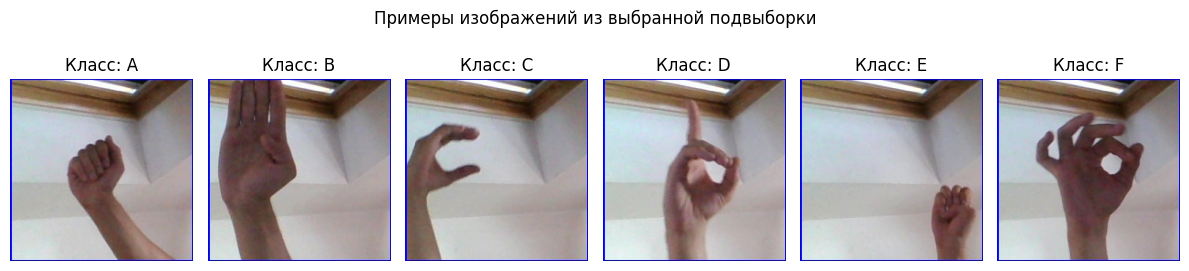

In [6]:
# визуальная проверка примеров изображений
examples = []
for cls in selected_classes:
    cls_paths = data_df[data_df["label"] == cls]["path"].tolist()
    if cls_paths:
        examples.append((cls, cls_paths[0]))

cols = min(6, len(examples))
plt.figure(figsize=(12, 3))
for i, (cls, img_path) in enumerate(examples[:cols], start=1):
    img = Image.open(img_path).convert("RGB")
    plt.subplot(1, cols, i)
    plt.imshow(img)
    plt.title(f"Класс: {cls}")
    plt.axis("off")
plt.suptitle("Примеры изображений из выбранной подвыборки")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "dataset_examples.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Предобработка данных

Для обучения нейросетевых моделей выполняются следующие шаги предобработки:

1. отбор ограниченного числа классов и изображений на класс;
2. преобразование изображений к единому размеру `64×64` пикселя;
3. перевод изображений в тензоры PyTorch;
4. нормализация значений пикселей;
5. разделение данных на обучающую, валидационную и тестовую выборки.

Такой подход позволяет быстро проверить работоспособность прототипа без обучения на полном объёме большого датасета.

In [7]:
# кодирование классов
class_names = selected_classes
class_to_idx = {cls: idx for idx, cls in enumerate(class_names)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}

# разделение данных: 70% train, 15% validation, 15% test
train_df, temp_df = train_test_split(
    data_df,
    test_size=0.30,
    random_state=SEED,
    stratify=data_df["label"],
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_df["label"],
)

split_table = pd.DataFrame({
    "Выборка": ["Обучающая", "Валидационная", "Тестовая", "Всего"],
    "Количество изображений": [len(train_df), len(val_df), len(test_df), len(data_df)],
    "Доля": [
        len(train_df) / len(data_df),
        len(val_df) / len(data_df),
        len(test_df) / len(data_df),
        1.0,
    ]
})

split_table

,Выборка,Количество изображений,Доля
0,Обучающая,840,0.70
1,Валидационная,180,0.15
2,Тестовая,180,0.15
3,Всего,1200,1.00


In [8]:
# трансформации изображений
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomRotation(10),
    T.RandomHorizontalFlip(p=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])


class ASLImageDataset(Dataset):
    """датасет изображений жестов для pytorch"""
    def __init__(self, dataframe: pd.DataFrame, class_to_idx: dict, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = row["path"]
        label_name = row["label"]
        label = self.class_to_idx[label_name]

        image = Image.open(image_path).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)

        return image, label


train_dataset = ASLImageDataset(train_df, class_to_idx, transform=train_transform)
val_dataset = ASLImageDataset(val_df, class_to_idx, transform=eval_transform)
test_dataset = ASLImageDataset(test_df, class_to_idx, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("Количество классов:", len(class_names))
print("Классы:", class_names)
print("Размер batch:", BATCH_SIZE)

Количество классов: 6
Классы: ['A', 'B', 'C', 'D', 'E', 'F']
Размер batch: 32


## 4. Создание нейросетевых моделей

Для сравнения реализованы две сверточные нейронные сети:

1. **SimpleCNN** - базовая CNN-модель с двумя сверточными блоками.
2. **ImprovedCNN** - улучшенная CNN-модель с большим числом сверточных слоев, BatchNorm и Dropout.

Сравнение двух моделей позволяет выполнить требование анализа эффективности и показать, как усложнение архитектуры влияет на качество классификации.

In [9]:
class SimpleCNN(nn.Module):
    """базовая сверточная нейронная сеть"""
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


class ImprovedCNN(nn.Module):
    """улучшенная cnn с batchnorm и dropout"""
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.35),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


num_classes = len(class_names)
model_1 = SimpleCNN(num_classes=num_classes).to(DEVICE)
model_2 = ImprovedCNN(num_classes=num_classes).to(DEVICE)

print(model_1)
print("-" * 80)
print(model_2)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32, out_features=6, bias=True)
  )
)
--------------------------------------------------------------------------------
ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), s

In [10]:
def count_parameters(model: nn.Module) -> int:
    """считает количество обучаемых параметров модели"""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

architecture_table = pd.DataFrame({
    "Модель": ["SimpleCNN", "ImprovedCNN"],
    "Краткое описание": [
        "2 сверточных блока + классификатор",
        "3 сверточных блока + BatchNorm + Dropout + классификатор",
    ],
    "Количество обучаемых параметров": [count_parameters(model_1), count_parameters(model_2)],
    "Входной тензор": [f"3×{IMG_SIZE}×{IMG_SIZE}", f"3×{IMG_SIZE}×{IMG_SIZE}"],
    "Выход": [f"{num_classes} классов", f"{num_classes} классов"],
})

architecture_table

,Модель,Краткое описание,Количество обучаемых параметров,Входной тензор,Выход
0,SimpleCNN,2 сверточных блока + классификатор,5286,3×64×64,6 классов
1,ImprovedCNN,3 сверточных блока + BatchNorm + Dropout + кла...,102342,3×64×64,6 классов


## 5. Обучение моделей

Модели обучаются на обучающей выборке, а после каждой эпохи качество проверяется на валидационной выборке. В качестве функции потерь используется `CrossEntropyLoss`, так как решается задача многоклассовой классификации.

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


@torch.no_grad()
def evaluate_loss_accuracy(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy


def fit_model(model, train_loader, val_loader, epochs, lr=1e-3, model_name="model"):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []
    best_state = None
    best_val_acc = -1

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion, DEVICE)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_acc,
            "val_loss": val_loss,
            "val_accuracy": val_acc,
        })

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        print(
            f"{model_name} | epoch {epoch}/{epochs} | "
            f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
            f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
        )

    if best_state is not None:
        model.load_state_dict(best_state)

    return pd.DataFrame(history), model

In [12]:
# обучение первой модели
history_1, model_1 = fit_model(
    model_1,
    train_loader,
    val_loader,
    epochs=EPOCHS_MODEL_1,
    lr=1e-3,
    model_name="SimpleCNN",
)

history_1

SimpleCNN | epoch 1/4 | train_loss=1.7955, train_acc=0.1595 | val_loss=1.7870, val_acc=0.1778
SimpleCNN | epoch 2/4 | train_loss=1.7889, train_acc=0.1821 | val_loss=1.7849, val_acc=0.2333
SimpleCNN | epoch 3/4 | train_loss=1.7873, train_acc=0.1750 | val_loss=1.7832, val_acc=0.2833
SimpleCNN | epoch 4/4 | train_loss=1.7857, train_acc=0.1667 | val_loss=1.7817, val_acc=0.1722


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.795525,0.159524,1.787007,0.177778
1,2,1.788911,0.182143,1.784938,0.233333
2,3,1.787295,0.175000,1.783194,0.283333
3,4,1.785731,0.166667,1.781748,0.172222


In [13]:
# обучение второй модели
history_2, model_2 = fit_model(
    model_2,
    train_loader,
    val_loader,
    epochs=EPOCHS_MODEL_2,
    lr=1e-3,
    model_name="ImprovedCNN",
)

history_2

ImprovedCNN | epoch 1/5 | train_loss=1.7716, train_acc=0.2321 | val_loss=1.7518, val_acc=0.1889
ImprovedCNN | epoch 2/5 | train_loss=1.6435, train_acc=0.3452 | val_loss=1.5777, val_acc=0.3611
ImprovedCNN | epoch 3/5 | train_loss=1.4535, train_acc=0.4417 | val_loss=1.3948, val_acc=0.4444
ImprovedCNN | epoch 4/5 | train_loss=1.3094, train_acc=0.4690 | val_loss=1.2817, val_acc=0.5000
ImprovedCNN | epoch 5/5 | train_loss=1.2259, train_acc=0.5143 | val_loss=1.1509, val_acc=0.5444


,epoch,train_loss,train_accuracy,val_loss,val_accuracy
0,1,1.771557,0.232143,1.751830,0.188889
1,2,1.643546,0.345238,1.577698,0.361111
2,3,1.453473,0.441667,1.394792,0.444444
3,4,1.309419,0.469048,1.281659,0.500000
4,5,1.225950,0.514286,1.150878,0.544444


## 6. Тестирование и метрики качества

Для итогового сравнения модели оцениваются на тестовой выборке по метрикам:

- `accuracy` - доля правильных предсказаний;
- `precision` - точность классификации;
- `recall` - полнота классификации;
- `F1-score` - гармоническое среднее precision и recall.

Используется усреднение `weighted`, так как оно учитывает количество объектов каждого класса.

In [14]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    for images, labels in loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy().tolist()
        y_pred.extend(preds)
        y_true.extend(labels.numpy().tolist())

    return np.array(y_true), np.array(y_pred)


def calculate_metrics(model, loader, model_name):
    y_true, y_pred = get_predictions(model, loader, DEVICE)
    return {
        "Модель": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }, y_true, y_pred


metrics_1, y_true_1, y_pred_1 = calculate_metrics(model_1, test_loader, "SimpleCNN")
metrics_2, y_true_2, y_pred_2 = calculate_metrics(model_2, test_loader, "ImprovedCNN")

# таблица 2: метрики качества моделей
metrics_table = pd.DataFrame([metrics_1, metrics_2])
metrics_table.to_csv(REPORTS_DIR / "metrics_table.csv", index=False, encoding="utf-8-sig")
metrics_table

,Модель,Accuracy,Precision,Recall,F1-score
0,SimpleCNN,0.266667,0.168803,0.266667,0.196612
1,ImprovedCNN,0.600000,0.581608,0.600000,0.562472


In [15]:
# определение лучшей модели по f1-score
best_row = metrics_table.sort_values("F1-score", ascending=False).iloc[0]
best_model_name = best_row["Модель"]

if best_model_name == "SimpleCNN":
    best_model = model_1
    best_history = history_1
    best_y_true, best_y_pred = y_true_1, y_pred_1
else:
    best_model = model_2
    best_history = history_2
    best_y_true, best_y_pred = y_true_2, y_pred_2

print("Лучшая модель:", best_model_name)
print(best_row)

Лучшая модель: ImprovedCNN
Модель       ImprovedCNN
Accuracy             0.6
Precision       0.581608
Recall               0.6
F1-score        0.562472
Name: 1, dtype: object


## 7. Графики и диаграммы результатов

Ниже представлены графики, необходимые для анализа промежуточных результатов:

1. график изменения функции потерь на обучении;
2. график изменения accuracy на валидации;
3. диаграмма сравнения итоговых метрик моделей;
4. матрица ошибок лучшей модели.

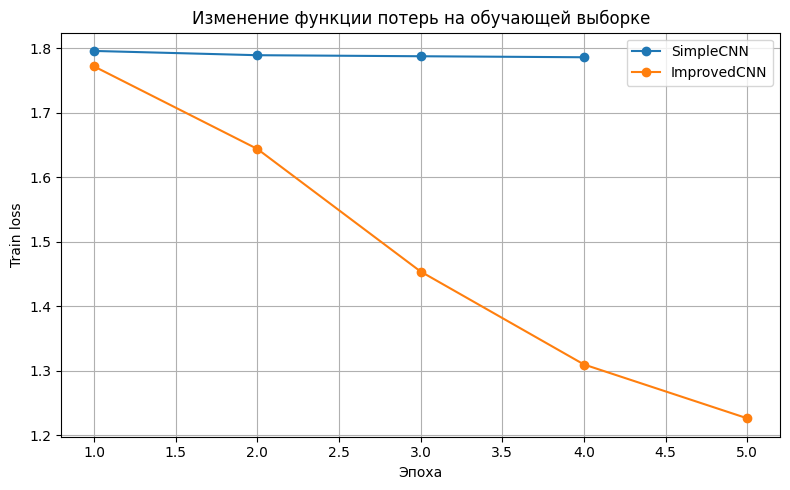

In [16]:
# график 1: изменение функции потерь на обучении
plt.figure(figsize=(8, 5))
plt.plot(history_1["epoch"], history_1["train_loss"], marker="o", label="SimpleCNN")
plt.plot(history_2["epoch"], history_2["train_loss"], marker="o", label="ImprovedCNN")
plt.title("Изменение функции потерь на обучающей выборке")
plt.xlabel("Эпоха")
plt.ylabel("Train loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "training_loss.png", dpi=150, bbox_inches="tight")
plt.show()

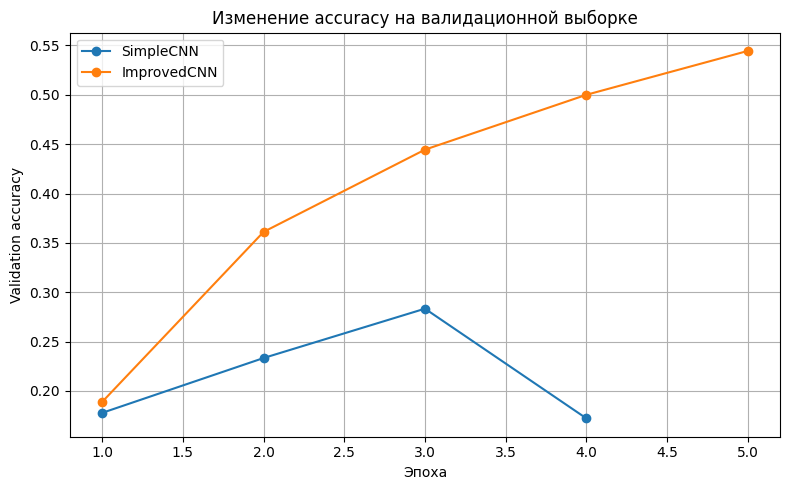

In [17]:
# график 2: изменение accuracy на валидационной выборке
plt.figure(figsize=(8, 5))
plt.plot(history_1["epoch"], history_1["val_accuracy"], marker="o", label="SimpleCNN")
plt.plot(history_2["epoch"], history_2["val_accuracy"], marker="o", label="ImprovedCNN")
plt.title("Изменение accuracy на валидационной выборке")
plt.xlabel("Эпоха")
plt.ylabel("Validation accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "validation_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

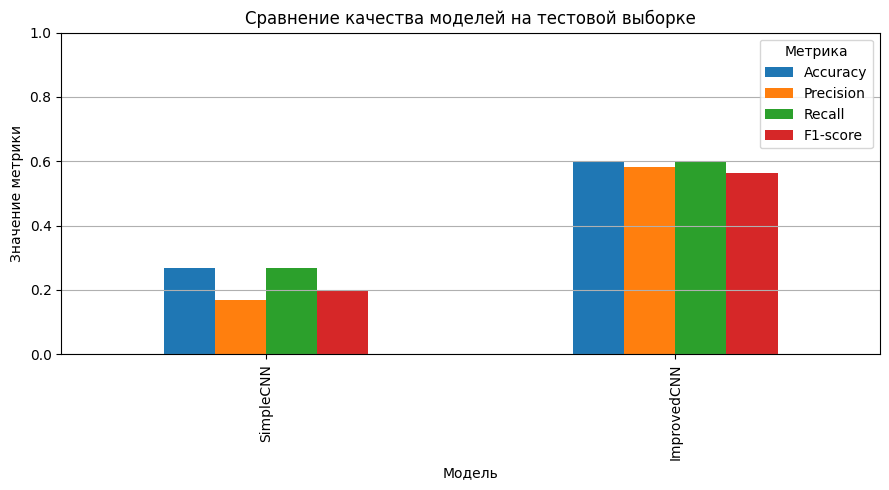

In [18]:
# график 3: сравнение итоговых метрик моделей
metric_columns = ["Accuracy", "Precision", "Recall", "F1-score"]
plot_df = metrics_table.set_index("Модель")[metric_columns]

ax = plot_df.plot(kind="bar", figsize=(9, 5))
plt.title("Сравнение качества моделей на тестовой выборке")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.ylim(0, 1)
plt.legend(title="Метрика")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

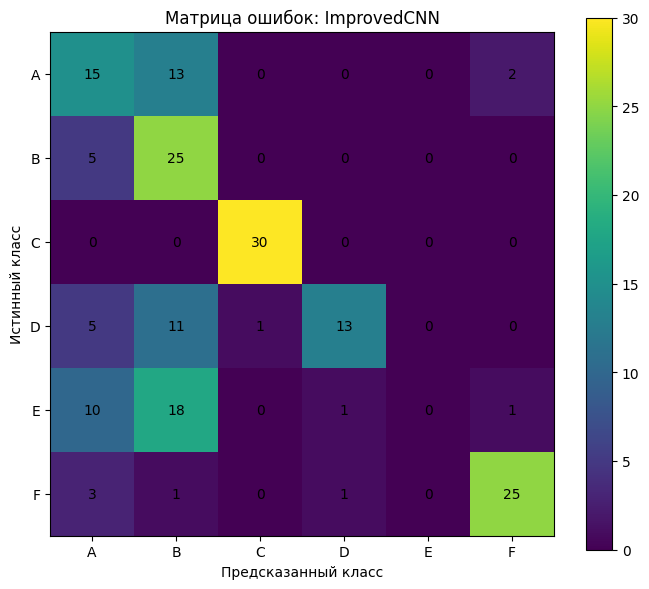

In [19]:
# диаграмма 4: матрица ошибок лучшей модели
cm = confusion_matrix(best_y_true, best_y_pred)

plt.figure(figsize=(7, 6))
plt.imshow(cm, interpolation="nearest")
plt.title(f"Матрица ошибок: {best_model_name}")
plt.xlabel("Предсказанный класс")
plt.ylabel("Истинный класс")
plt.xticks(range(len(class_names)), class_names)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
# подробная таблица качества по классам для лучшей модели
report_dict = classification_report(
    best_y_true,
    best_y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

class_report_table = pd.DataFrame(report_dict).T
class_report_table.to_csv(REPORTS_DIR / "classification_report.csv", encoding="utf-8-sig")
class_report_table

,precision,recall,f1-score,support
A,0.394737,0.500000,0.441176,30.0
B,0.367647,0.833333,0.510204,30.0
C,0.967742,1.000000,0.983607,30.0
D,0.866667,0.433333,0.577778,30.0
E,0.000000,0.000000,0.000000,30.0
F,0.892857,0.833333,0.862069,30.0
accuracy,0.600000,0.600000,0.600000,0.6
macro avg,0.581608,0.600000,0.562472,180.0
weighted avg,0.581608,0.600000,0.562472,180.0


## 8. Вывод архитектуры модели через `torchinfo`

Нам нужно показать архитектуру модели: слои, размерности тензоров и количество параметров. Для этого используется `torchinfo.summary()`.



In [21]:
# вывод архитектуры модели через torchinfo
best_model = best_model.to(DEVICE)
best_model.eval()

from torchinfo import summary

model_summary = summary(
    best_model,
    input_size=(1, 3, IMG_SIZE, IMG_SIZE),
    col_names=("input_size", "output_size", "num_params", "trainable"),
    verbose=0,
    device=DEVICE,
)

print(model_summary)

with open(REPORTS_DIR / "torchinfo_summary.txt", "w", encoding="utf-8") as file:
    file.write(str(model_summary))


Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
ImprovedCNN                              [1, 3, 64, 64]            [1, 6]                    --                        True
├─Sequential: 1-1                        [1, 3, 64, 64]            [1, 128, 1, 1]            --                        True
│    └─Conv2d: 2-1                       [1, 3, 64, 64]            [1, 32, 64, 64]           896                       True
│    └─BatchNorm2d: 2-2                  [1, 32, 64, 64]           [1, 32, 64, 64]           64                        True
│    └─ReLU: 2-3                         [1, 32, 64, 64]           [1, 32, 64, 64]           --                        --
│    └─MaxPool2d: 2-4                    [1, 32, 64, 64]           [1, 32, 32, 32]           --                        --
│    └─Conv2d: 2-5                       [1, 32, 32, 32]           [1, 64, 32, 32]           18,496                    True
│    └─

## 9. Сохранение модели и подготовка файла для Netron

Лучшая модель сохраняется в двух форматах:

1. `.pth` - PyTorch checkpoint с весами модели, названиями классов и метриками;
2. `.pt` - TorchScript-модель, которую можно открыть в Netron для визуализации архитектуры.


In [22]:
# сохранение лучшей модели
best_model_cpu = copy.deepcopy(best_model).cpu().eval()

checkpoint_path = MODELS_DIR / "best_model_checkpoint.pth"
torch.save({
    "model_name": best_model_name,
    "model_state_dict": best_model_cpu.state_dict(),
    "class_names": class_names,
    "img_size": IMG_SIZE,
    "metrics": best_row.to_dict(),
}, checkpoint_path)

print("PyTorch checkpoint сохранён:", checkpoint_path)

# torchscript-файл для netron
example_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
torchscript_path = MODELS_DIR / "best_model_torchscript.pt"

traced_model = torch.jit.trace(best_model_cpu, example_input)
traced_model.save(str(torchscript_path))

print("TorchScript модель для Netron сохранена:", torchscript_path)


PyTorch checkpoint сохранён: C:\Users\evape\Downloads\sign-language-recognition\models\best_model_checkpoint.pth
TorchScript модель для Netron сохранена: C:\Users\evape\Downloads\sign-language-recognition\models\best_model_torchscript.pt


## 10. Рабочий прототип: предсказание жеста по изображению

Функция `predict_image()` принимает путь к изображению, выполняет такую же предобработку, как для тестовой выборки, и возвращает наиболее вероятные классы жеста.

Эта функция используется как минимальный рабочий прототип: на вход подаётся изображение руки, на выходе получается предсказанный класс жеста.


Тестовое изображение: C:\Users\evape\Downloads\sign-language-recognition\data\asl_dataset\C\C1696.jpg


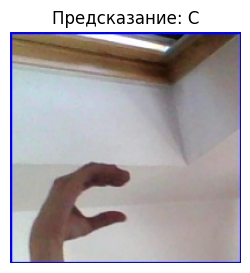

,Класс,Вероятность
0,C,0.921395
1,D,0.044257
2,E,0.015807


In [23]:
def predict_image(image_path, model=None, top_k=3, show_image=True):
    """предсказывает класс жеста по одному изображению"""
    if model is None:
        model = best_model_cpu

    model.eval()
    image_path = Path(image_path)
    image = Image.open(image_path).convert("RGB")
    input_tensor = eval_transform(image).unsqueeze(0)

    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.softmax(outputs, dim=1).squeeze(0)
        top_probs, top_indices = torch.topk(probabilities, k=min(top_k, len(class_names)))

    result = pd.DataFrame({
        "Класс": [idx_to_class[int(i)] for i in top_indices],
        "Вероятность": [float(p) for p in top_probs],
    })

    if show_image:
        plt.figure(figsize=(3, 3))
        plt.imshow(image)
        plt.title(f"Предсказание: {result.iloc[0]['Класс']}")
        plt.axis("off")
        plt.show()

    return result


# проверка прототипа на одном изображении из тестовой выборки
sample_image_path = test_df.iloc[0]["path"]
print("Тестовое изображение:", sample_image_path)
predict_image(sample_image_path, top_k=3)

## 11. Краткий анализ результатов

В ходе работы был реализован прототип распознавания жестов руки по изображениям. Для обучения использовалась подвыборка датасета ASL Alphabet: 6 классов (`A-F`) и 1200 изображений суммарно. Данные были разделены на обучающую, валидационную и тестовую выборки.

Были обучены две сверточные модели: базовая `SimpleCNN` и более сложная `ImprovedCNN`. По результатам тестирования лучшей оказалась модель `ImprovedCNN`: она показала более высокие значения `accuracy`, `precision`, `recall` и `F1-score`, чем базовая модель. Это видно и по таблице метрик, и по диаграмме сравнения качества моделей.

Матрица ошибок показывает, что часть классов распознаётся уверенно, например отдельные жесты почти не смешиваются с другими. При этом по некоторым классам есть ошибки: это может быть связано с визуальной похожестью жестов, небольшим числом эпох и тем, что использовалась ограниченная подвыборка данных. Поэтому текущие результаты можно считать рабочими для промежуточного прототипа, но не финальными для полноценной системы распознавания жестового языка.

Дальнейшее улучшение проекта возможно за счёт увеличения числа эпох, расширения набора классов, использования полного датасета, подбора гиперпараметров и применения transfer learning.


## 12. Текущее состояние разработки и реализованная функциональность

На текущем этапе готов рабочий прототип распознавания жестов руки по изображениям.

**Реализовано:**

- подключение открытого датасета ASL Alphabet;
- подключение папок классов из локального датасета;
- формирование ограниченной подвыборки для ускорения обучения;
- предобработка изображений: изменение размера, нормализация, перевод в тензоры;
- разбиение данных на обучающую, валидационную и тестовую выборки;
- реализация двух CNN-моделей на PyTorch;
- обучение и валидация моделей;
- расчёт метрик `accuracy`, `precision`, `recall`, `F1-score`;
- построение таблиц с описанием данных, архитектур и результатов тестирования;
- построение графиков функции потерь, accuracy, сравнения метрик и матрицы ошибок;
- вывод архитектуры модели через `torchinfo`;
- сохранение лучшей модели в форматах `.pth` и `.pt`;
- подготовка TorchScript-файла для просмотра архитектуры в Netron;
- функция `predict_image()` для распознавания жеста по отдельному изображению.


## 13. Итоговые файлы

После выполнения всех ячеек в папке проекта создаются следующие файлы:

```text
images/
├── dataset_examples.png
├── training_loss.png
├── validation_accuracy.png
├── metrics_comparison.png
└── confusion_matrix.png

models/
├── best_model_checkpoint.pth
└── best_model_torchscript.pt

reports/
├── metrics_table.csv
├── classification_report.csv
└── torchinfo_summary.txt
```

Эти файлы также находятся в GitHub-репозитории вместе с ноутбуком и README. Отдельно также там находится скриншот из Netron.
